##### Copyright 2024 Google LLC.

In [ ]:
# @title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Get started with the Gemini API: Python

<table class="tfo-notebook-buttons" align="left">
  <td>
    <a target="_blank" href="https://ai.google.dev/gemini-api/docs/get-started/python"><img src="https://ai.google.dev/static/site-assets/images/docs/notebook-site-button.png" height="32" width="32" />View on Google AI</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/google/generative-ai-docs/blob/main/site/en/gemini-api/docs/get-started/python.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/google/generative-ai-docs/blob/main/site/en/gemini-api/docs/get-started/python.ipynb"><img src="https://www.tensorflow.org/images/GitHub-Mark-32px.png" />View source on GitHub</a>
  </td>
</table>

This quickstart demonstrates how to use the Python SDK for the Gemini API, which gives you access to Google's Gemini large language models. In this quickstart, you will learn how to:

1. Set up your development environment and API access to use Gemini.
2. Generate text responses from text inputs.
3. Generate text responses from multimodal inputs (text and images).
4. Use Gemini for multi-turn conversations (chat).
5. Use embeddings for large language models.

## Prerequisites

You can run this quickstart in [Google Colab](https://colab.research.google.com/github/google/generative-ai-docs/blob/main/site/en/gemini-api/docs/get-started/python.ipynb), which runs this notebook directly in the browser and does not require additional environment configuration.

Alternatively, to complete this quickstart locally, ensure that your development environment meets the following requirements:

-  Python 3.9+
-  An installation of `jupyter` to run the notebook.

## Setup

### Install the Python SDK

The Python SDK for the Gemini API, is contained in the [`google-generativeai`](https://pypi.org/project/google-generativeai/) package. Install the dependency using pip:

In [60]:
!pip install -q -U google-generativeai

### Import packages

Import the necessary packages.

In [61]:
import pathlib
import textwrap

import google.generativeai as genai

from IPython.display import display
from IPython.display import Markdown


def to_markdown(text)->Markdown:
    text : str = text.replace("•", "  *")
    return Markdown(textwrap.indent(text, "> ", predicate=lambda _: True))

In [62]:
# Used to securely store your API key
from google.colab import userdata

### Setup your API key

Before you can use the Gemini API, you must first obtain an API key. If you don't already have one, create a key with one click in Google AI Studio.

<a class="button button-primary" href="https://makersuite.google.com/app/apikey" target="_blank" rel="noopener noreferrer">Get an API key</a>

Note that depending on where you are located, you might have to [enable billing](https://ai.google.dev/gemini-api/docs/billing#enable-cloud-billing) since the free tier is not available in [EEA (including EU), the UK, and CH](https://ai.google.dev/gemini-api/docs/billing#is-Gemini-free-in-EEA-UK-CH)

In Colab, add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GEMINI_API_KEY`.

Once you have the API key, pass it to the SDK. You can do this in two ways:

* Put the key in the `GEMINI_API_KEY` environment variable (the SDK will automatically pick it up from there).
* Pass the key to `genai.configure(api_key=...)`

In [63]:
# Or use `os.getenv('GEMINI_API_KEY')` to fetch an environment variable.
GEMINI_API_KEY : str = userdata.get("GEMINI_API_KEY")

genai.configure(api_key=GEMINI_API_KEY)

## List models

Now you're ready to call the Gemini API. Use `list_models` to see the available Gemini models:

* `gemini-1.5-flash`: optimized for multi-modal use-cases where speed and cost are important. This should be your go-to model.
* `gemini-1.5-pro`: optimized for high intelligence tasks, the most powerful Gemini model

[Model(name='models/text-embedding-004',
       base_model_id='',
       version='004',
       display_name='Text Embedding 004',
       description='Obtain a distributed representation of a text.',
       input_token_limit=2048,
       output_token_limit=1,
       supported_generation_methods=['embedContent'],
       temperature=None,
       max_temperature=None,
       top_p=None,
       top_k=None)]

In [64]:
list(genai.list_models())

[Model(name='models/chat-bison-001',
       base_model_id='',
       version='001',
       display_name='PaLM 2 Chat (Legacy)',
       description='A legacy text-only model optimized for chat conversations',
       input_token_limit=4096,
       output_token_limit=1024,
       supported_generation_methods=['generateMessage', 'countMessageTokens'],
       temperature=0.25,
       max_temperature=None,
       top_p=0.95,
       top_k=40),
 Model(name='models/text-bison-001',
       base_model_id='',
       version='001',
       display_name='PaLM 2 (Legacy)',
       description='A legacy model that understands text and generates text as an output',
       input_token_limit=8196,
       output_token_limit=1024,
       supported_generation_methods=['generateText', 'countTextTokens', 'createTunedTextModel'],
       temperature=0.7,
       max_temperature=None,
       top_p=0.95,
       top_k=40),
 Model(name='models/embedding-gecko-001',
       base_model_id='',
       version='001',
      

In [65]:
for idx, m in enumerate(genai.list_models()):
    if "generateContent" in m.supported_generation_methods:
        print(f'sno {idx} name {m.name}')

sno 3 name models/gemini-1.0-pro-latest
sno 4 name models/gemini-1.0-pro
sno 5 name models/gemini-pro
sno 6 name models/gemini-1.0-pro-001
sno 7 name models/gemini-1.0-pro-vision-latest
sno 8 name models/gemini-pro-vision
sno 9 name models/gemini-1.5-pro-latest
sno 10 name models/gemini-1.5-pro-001
sno 11 name models/gemini-1.5-pro-002
sno 12 name models/gemini-1.5-pro
sno 13 name models/gemini-1.5-pro-exp-0801
sno 14 name models/gemini-1.5-pro-exp-0827
sno 15 name models/gemini-1.5-flash-latest
sno 16 name models/gemini-1.5-flash-001
sno 17 name models/gemini-1.5-flash-001-tuning
sno 18 name models/gemini-1.5-flash
sno 19 name models/gemini-1.5-flash-exp-0827
sno 20 name models/gemini-1.5-flash-002
sno 21 name models/gemini-1.5-flash-8b
sno 22 name models/gemini-1.5-flash-8b-001
sno 23 name models/gemini-1.5-flash-8b-latest
sno 24 name models/gemini-1.5-flash-8b-exp-0827
sno 25 name models/gemini-1.5-flash-8b-exp-0924
sno 26 name models/learnlm-1.5-pro-experimental
sno 27 name models/

Note: For detailed information about the available models, including their capabilities and rate limits, see [Gemini models](https://ai.google.dev/models/gemini). There are options for requesting [rate limit increases](https://ai.google.dev/docs/increase_quota). The rate limit for Gemini-Flash models is 15 requests per minute (RPM) for free ([in supported countries](https://ai.google.dev/gemini-api/docs/billing#is-Gemini-free-in-EEA-UK-CH)).

The `genai` package also supports the PaLM  family of models, but only the Gemini models support the generic, multimodal capabilities of the `generateContent` method.

## Generate text from text inputs

Always start with the 'gemini-1.5-flash' model. It should be sufficient for most of your tasks:

In [66]:
from google.generativeai import GenerativeModel

model : GenerativeModel = genai.GenerativeModel("gemini-1.5-flash")

The `generate_content` method can handle a wide variety of use cases, including multi-turn chat and multimodal input, depending on what the underlying model supports. At the moment, the available models support text, images and videos as input, and text as output.

In the simplest case, you can pass a prompt string to the <a href="https://ai.google.dev/api/generate-content#v1beta.models.generateContent"><code>GenerativeModel.generate_content</code></a> method:

In [67]:
%%time
from google.generativeai.types.generation_types import GenerateContentResponse

response : GenerateContentResponse = model.generate_content("What is the meaning of life?")
response.text

CPU times: user 78.5 ms, sys: 9.81 ms, total: 88.3 ms
Wall time: 4.59 s


"There's no single, universally accepted answer to the meaning of life.  The meaning of life is a deeply personal and philosophical question that has been pondered by humans for millennia.  Different people, cultures, and philosophies offer diverse perspectives.  Some common viewpoints include:\n\n* **Nihilism:**  The belief that life is inherently meaningless.\n* **Existentialism:** The belief that life is inherently meaningless, but that we create our own meaning and purpose through our choices and actions.\n* **Absurdism:**  The belief that the search for meaning in a meaningless universe is inherently absurd, but that we should embrace this absurdity.\n* **Spiritual and Religious Beliefs:** Many religions provide answers about the meaning of life, often involving a higher power, an afterlife, and a divine purpose.  These meanings vary widely depending on the specific religion.\n* **Hedonism:** The belief that the meaning of life is to pursue pleasure and avoid pain.\n* **Purpose-Dr

In simple cases, the `response.text` accessor is all you need. To display formatted Markdown text, use the `to_markdown` function:

In [68]:
to_markdown(response.text)

> There's no single, universally accepted answer to the meaning of life.  The meaning of life is a deeply personal and philosophical question that has been pondered by humans for millennia.  Different people, cultures, and philosophies offer diverse perspectives.  Some common viewpoints include:
> 
> * **Nihilism:**  The belief that life is inherently meaningless.
> * **Existentialism:** The belief that life is inherently meaningless, but that we create our own meaning and purpose through our choices and actions.
> * **Absurdism:**  The belief that the search for meaning in a meaningless universe is inherently absurd, but that we should embrace this absurdity.
> * **Spiritual and Religious Beliefs:** Many religions provide answers about the meaning of life, often involving a higher power, an afterlife, and a divine purpose.  These meanings vary widely depending on the specific religion.
> * **Hedonism:** The belief that the meaning of life is to pursue pleasure and avoid pain.
> * **Purpose-Driven Life:**  The belief that meaning comes from pursuing a purpose, whether it's contributing to society, achieving personal goals, or leaving a legacy.
> 
> Ultimately, the meaning of life is what you make it.  It's a question of personal reflection and discovery.  There's no right or wrong answer, only the answer that resonates most deeply with you.


If the API failed to return a result, use `GenerateContentResponse.prompt_feedback` to see if it was blocked due to safety concerns regarding the prompt.

In [69]:
response.prompt_feedback

Gemini can generate multiple possible responses for a single prompt. These possible responses are called `candidates`, and you can review them to select the most suitable one as the response.

View the response candidates with <a href="https://ai.google.dev/api/python/google/generativeai/protos/GenerateContentResponse#candidates"><code>GenerateContentResponse.candidates</code></a>:

In [ ]:
response.candidates[0].content.parts[0].text

'The meaning of life is a question that has been pondered by philosophers and theologians for centuries. There is no single answer that everyone agrees on, as the meaning of life is a deeply personal and subjective question. \n\nHere are some different perspectives:\n\n**Philosophical Perspectives:**\n\n* **Nihilism:**  The belief that life has no inherent meaning or purpose.\n* **Existentialism:**  Emphasizes individual freedom and responsibility to create meaning in a meaningless universe.\n* **Absurdism:**  Acknowledges the inherent absurdity of life, yet encourages embracing it and finding joy in the face of meaninglessness.\n* **Hedonism:**  Focuses on maximizing pleasure and minimizing pain.\n* **Utilitarianism:**  Defines the good as maximizing happiness for the greatest number of people.\n* **Stoicism:**  Focuses on accepting what is beyond our control and focusing on what we can control, like our own thoughts and actions.\n\n**Religious Perspectives:**\n\n* **Monotheistic reli

By default, the model returns a response after completing the entire generation process. You can also stream the response as it is being generated, and the model will return chunks of the response as soon as they are generated.

To stream responses, use <a href="https://ai.google.dev/api/python/google/generativeai/GenerativeModel#generate_content"><code>GenerativeModel.generate_content(..., stream=True)</code></a>.

In [70]:
%%time

from google.generativeai.types.generation_types import GenerateContentResponse

response : GenerateContentResponse = model.generate_content("What is the meaning of life?", stream=True)

CPU times: user 95.8 ms, sys: 8.8 ms, total: 105 ms
Wall time: 5.29 s


In [71]:
for chunk in model.generate_content("What is the meaning of life?", stream=True):
    print(chunk.text)
    print("_" * 80)

There
________________________________________________________________________________
's no single, universally agreed-upon answer to the meaning of life.
________________________________________________________________________________
  The question itself is philosophical, and different philosophies and individuals offer vastly different perspectives
________________________________________________________________________________
.  Some common viewpoints include:

* **Nihilism:**  The belief that life is inherently without meaning or purpose.
* **Existentialism
________________________________________________________________________________
:**  The belief that individuals create their own meaning and purpose through their choices and actions.  There's no predetermined meaning; we must define it for ourselves
________________________________________________________________________________
.
* **Absurdism:**  Acknowledges the conflict between the human search for meaning and the mea

When streaming, some response attributes are not available until you've iterated through all the response chunks. This is demonstrated below:

In [72]:
from google.generativeai.types.generation_types import GenerateContentResponse

response: GenerateContentResponse = model.generate_content("What is the meaning of life?", stream=True)

The `prompt_feedback` attribute works:

In [75]:
response.prompt_feedback

In [76]:
response

response:
GenerateContentResponse(
    done=False,
    iterator=<ResponseIterator>,
    result=protos.GenerateContentResponse({
      "candidates": [
        {
          "content": {
            "parts": [
              {
                "text": "There"
              }
            ],
            "role": "model"
          }
        }
      ],
      "usage_metadata": {
        "prompt_token_count": 8,
        "total_token_count": 8
      }
    }),
)

But attributes like <code>text</code> do not:

In [77]:
try:
    response.text
except Exception as e:
    print(f"{type(e).__name__}: {e}")

IncompleteIterationError: Please let the response complete iteration before accessing the final accumulated
attributes (or call `response.resolve()`)


In [78]:
response.resolve()


In [80]:
response.text

"There's no single, universally accepted answer to the meaning of life.  It's a question that has been pondered by philosophers, theologians, and individuals for centuries.  The meaning, if any, is often considered to be subjective and personal.\n\nSome common perspectives include:\n\n* **Nihilism:** The belief that life is inherently without meaning or purpose.\n* **Existentialism:** The belief that individuals create their own meaning and purpose through their choices and actions.\n* **Absurdism:** The belief that the search for meaning in a meaningless universe is inherently absurd, but that we should embrace this absurdity.\n* **Spiritual and Religious Beliefs:** Many religions offer answers about the meaning of life, often involving serving a higher power, achieving enlightenment, or following a divine plan.\n* **Hedonism:** The belief that pleasure and happiness are the ultimate goals in life.\n* **Purpose-driven life:**  Finding meaning through contributing to something larger t

In [90]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Generate text from image and text inputs

The `GenerativeModel.generate_content` API is designed to handle multimodal prompts and returns a text output.

Let's include an image:

In [119]:
!curl -o image.jpg https://i.ndtvimg.com/i/2017-06/nihari_650x400_81498470650.jpg

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 98678  100 98678    0     0   559k      0 --:--:-- --:--:-- --:--:--  563k


In [120]:
pwd

'/content'

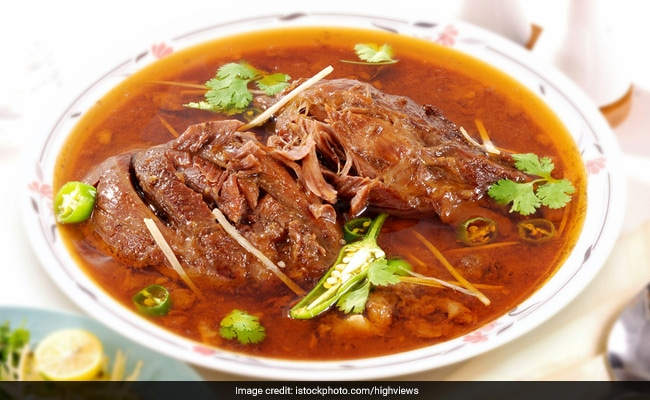

In [121]:
import PIL.Image

img = PIL.Image.open("/content/image.jpg")
img

Use the `gemini-1.5-flash` model and pass the image to the model with `generate_content`.

In [107]:
model : GenerativeModel = genai.GenerativeModel("gemini-1.5-flash")

In [122]:
from google.generativeai.types.generation_types import GenerateContentResponse

response : GenerateContentResponse = model.generate_content(
    [
        "Describe this image",  # Add a text prompt
        img,
    ]
)

to_markdown(response.text)

> That's a close-up shot of a bowl of Nihari, a slow-cooked South Asian meat stew. 
> 
> 
> Specifically, the image shows:
> 
> * **A shallow, wide bowl:**  A white bowl with a subtle floral or decorative pattern is filled with the Nihari.
> * **Rich, dark brown stew:** The stew is the dominant feature, exhibiting a thick, reddish-brown gravy.  The meat is visible, appearing tender and falling apart.
> * **Chunks of meat:**  Large pieces of what appears to be beef or lamb are prominently displayed. The meat is dark in color from the long cooking process.
> * **Garnish:** The dish is garnished with fresh cilantro (coriander) and bright green chilies.
> * **Other elements (partially visible):**  A blurred background suggests other food items, possibly lemon slices, are nearby on a table.
> 
> The overall impression is one of rich, flavorful, and hearty cuisine. The lighting and photography highlight the texture and color of the Nihari, making it visually appealing.


To provide both text and images in a prompt, pass a list containing the strings and images:

In [ ]:
from google.generativeai.types.generation_types import GenerateContentResponse

response : GenerateContentResponse = model.generate_content(
    [
        "Write a short, engaging blog post based on this picture. It should include a description of the meal in the photo and talk about my journey meal prepping.",
        img,
    ],
    stream=True,
)
response.resolve()

In [ ]:
to_markdown(response.text)

> ##  My Meal Prep Journey: From Chaos to Calm
> 
> This is my lunch for the week: a delightful medley of teriyaki chicken, fluffy white rice, crisp broccoli florets, and vibrant red and orange peppers. And it's all ready to go! 
> 
> I used to dread meal prep. I'd spend hours in the kitchen, only to end up with a fridge full of sad, soggy leftovers. But then, I discovered the magic of meal prepping strategically. 
> 
> My secret? Planning! I now choose recipes that can be prepped in bulk, like this teriyaki chicken. I chop my veggies and cook my rice in advance, so all I have to do is assemble my lunches on Sunday night. 
> 
> The result? Delicious, healthy meals that are ready in minutes, leaving me with more time to do the things I love (like not cooking!). 
> 
> What are some of your favorite meal prep tips? Share them in the comments below! 


## Chat conversations

Gemini enables you to have freeform conversations across multiple turns. The `ChatSession` class simplifies the process by managing the state of the conversation, so unlike with `generate_content`, you do not have to store the conversation history as a list.

Initialize the chat:

In [ ]:

from google.generativeai.types.generation_types import GenerateContentResponse
from google.generativeai.generative_models import ChatSession


model : GenerateContentResponse = genai.GenerativeModel("gemini-1.5-flash")


chat : ChatSession = model.start_chat(history=[])
chat

ChatSession(
    model=genai.GenerativeModel(
        model_name='models/gemini-1.5-flash',
        generation_config={},
        safety_settings={},
        tools=None,
        system_instruction=None,
        cached_content=None
    ),
    history=[]
)

The `ChatSession.send_message` method returns the same `GenerateContentResponse` type as <a href="https://github.com/google-gemini/generative-ai-python/blob/main/docs/api/google/generativeai/generate_text.md"><code>GenerativeModel.generate_content</code></a>. It also appends your message and the response to the chat history:

In [ ]:
from google.generativeai.types.generation_types import GenerateContentResponse

response : GenerateContentResponse = chat.send_message(
    "In one sentence, explain how a computer works to a young child."
)
to_markdown(response.text)

> A computer is like a super smart toy that uses electricity to follow instructions and show you things on a screen. 


In [ ]:
chat.history

[parts {
   text: "In one sentence, explain how a computer works to a young child."
 }
 role: "user",
 parts {
   text: "A computer is like a super smart toy that uses electricity to follow instructions and show you things on a screen. \n"
 }
 role: "model"]

You can keep sending messages to continue the conversation. Use the `stream=True` argument to stream the chat:

In [ ]:
from google.generativeai.types.generation_types import GenerateContentResponse

response : GenerateContentResponse = chat.send_message(
    "Okay, how about a more detailed explanation to a high schooler?", stream=True
)

for chunk in response:
    print(chunk.text)
    print("_" * 80)

Computers
________________________________________________________________________________
 work by taking your instructions, turning them into a language of ones and zeros,
________________________________________________________________________________
 processing that information, and then translating it back into something you can understand, like
________________________________________________________________________________
 text, images, or sounds. 

________________________________________________________________________________


[`genai.protos.Content`](https://github.com/google-gemini/generative-ai-python/blob/main/docs/api/google/generativeai/protos/Content.md) objects contain a list of [`genai.protos.Part`](https://github.com/google-gemini/generative-ai-python/blob/main/docs/api/google/generativeai/protos/Part.md) objects that each contain either a text (string) or inline_data ([`genai.protos.Blob`](https://github.com/google-gemini/generative-ai-python/blob/main/docs/api/google/generativeai/protos/Blob.md)), where a blob contains binary data and a `mime_type`. The chat history is available as a list of `genai.protos.Content` objects in `ChatSession.history`:

In [ ]:
for message in chat.history:
    display(to_markdown(f"**{message.role}**: {message.parts[0].text}"))

> **user**: In one sentence, explain how a computer works to a young child.

> **model**: A computer is like a super smart toy that uses electricity to follow instructions and show you things on a screen. 


> **user**: Okay, how about a more detailed explanation to a high schooler?

> **model**: Computers work by taking your instructions, turning them into a language of ones and zeros, processing that information, and then translating it back into something you can understand, like text, images, or sounds. 


## Count tokens

Large language models have a context window, and the context length is often measured in terms of the **number of tokens**. With the Gemini API, you can determine the number of tokens per any `genai.protos.Content` object. In the simplest case, you can pass a query string to the `GenerativeModel.count_tokens` method as follows:

In [ ]:
model.count_tokens("What is the meaning of life?")

total_tokens: 7

Similarly, you can check `token_count` for your `ChatSession`:

In [ ]:
model.count_tokens(chat.history)

total_tokens: 98

## Advanced use cases

The following sections discuss advanced use cases and lower-level details of the Python SDK for the Gemini API.

### Use embeddings

[Embedding](https://developers.google.com/machine-learning/glossary#embedding-vector) is a technique used to represent information as a list of floating point numbers in an array. With Gemini, you can represent text (words, sentences, and blocks of text) in a vectorized form, making it easier to compare and contrast embeddings. For example, two texts that share a similar subject matter or sentiment should have similar embeddings, which can be identified through mathematical comparison techniques such as cosine similarity. For more on how and why you should use embeddings, refer to the [Embeddings guide](https://ai.google.dev/docs/embeddings_guide).

Use the `embed_content` method to generate embeddings. The method handles embedding for the following tasks (`task_type`):

Task Type | Description
---       | ---
RETRIEVAL_QUERY	| Specifies the given text is a query in a search/retrieval setting.
RETRIEVAL_DOCUMENT | Specifies the given text is a document in a search/retrieval setting. Using this task type requires a `title`.
SEMANTIC_SIMILARITY	| Specifies the given text will be used for Semantic Textual Similarity (STS).
CLASSIFICATION	| Specifies that the embeddings will be used for classification.
CLUSTERING	| Specifies that the embeddings will be used for clustering.

The following generates an embedding for a single string for document retrieval:

In [ ]:
[i for i in genai.list_models() if 'models/text-embedding-004' in i.name]

[Model(name='models/text-embedding-004',
       base_model_id='',
       version='004',
       display_name='Text Embedding 004',
       description='Obtain a distributed representation of a text.',
       input_token_limit=2048,
       output_token_limit=1,
       supported_generation_methods=['embedContent'],
       temperature=None,
       max_temperature=None,
       top_p=None,
       top_k=None)]

In [ ]:
from typing import Dict

result : Dict = genai.embed_content(
    model="models/text-embedding-004",
    content="What is the meaning of life?",
    task_type="retrieval_document",
    title="Embedding of single string",
)

# 1 input > 1 vector output
print(str(result["embedding"])[:50], "... TRIMMED]")

[-0.028545432, 0.044588123, -0.03419736, -0.004266 ... TRIMMED]


In [ ]:
len(result['embedding'])

768

Note: The `retrieval_document` task type is the only task that accepts a title.

To handle batches of strings, pass a list of strings in `content`:

In [ ]:
from typing import Dict

result : Dict = genai.embed_content(
    model="models/text-embedding-004",
    content=[
        "What is the meaning of life?",
        "How much wood would a woodchuck chuck?",
        "How does the brain work?",
    ],
    task_type="retrieval_document",
    title="Embedding of list of strings",
)

# A list of inputs > A list of vectors output
for v in result["embedding"]:
    print(str(v)[:50], "... TRIMMED ...")

[-0.036453035, 0.03325499, -0.03970925, -0.0026286 ... TRIMMED ...
[-0.01591948, 0.032582667, -0.081024624, -0.011298 ... TRIMMED ...
[0.00037063262, 0.03763057, -0.12269569, -0.009518 ... TRIMMED ...


While the `genai.embed_content` function accepts simple strings or lists of strings, it is actually built around the `genai.protos.Content` type (like <a href="https://ai.google.dev/api/python/google/generativeai/GenerativeModel#generate_content"><code>GenerativeModel.generate_content</code></a>). `genai.protos.Content` objects are the primary units of conversation in the API.

While the `genai.protos.Content` object is multimodal, the `embed_content` method only supports text embeddings. This design gives the API the *possibility* to expand to multimodal embeddings.

In [ ]:
response.candidates[0].content

parts {
  text: "Computers work by taking your instructions, turning them into a language of ones and zeros, processing that information, and then translating it back into something you can understand, like text, images, or sounds. \n"
}
role: "model"

In [ ]:
from typing import Dict

result : Dict = genai.embed_content(
    model="models/text-embedding-004", content=response.candidates[0].content
)

# 1 input > 1 vector output
print(str(result["embedding"])[:50], "... TRIMMED ...")

[-0.036433354, 0.03981045, -0.03882044, -0.0388146 ... TRIMMED ...


Similarly, the chat history contains a list of `genai.protos.Content` objects, which you can pass directly to the `embed_content` function:

In [ ]:
chat.history

[parts {
   text: "In one sentence, explain how a computer works to a young child."
 }
 role: "user",
 parts {
   text: "A computer is like a super smart toy that uses electricity to follow instructions and show you things on a screen. \n"
 }
 role: "model",
 parts {
   text: "Okay, how about a more detailed explanation to a high schooler?"
 }
 role: "user",
 parts {
   text: "Computers work by taking your instructions, turning them into a language of ones and zeros, processing that information, and then translating it back into something you can understand, like text, images, or sounds. \n"
 }
 role: "model"]

In [ ]:
from typing import Dict

result : Dict = genai.embed_content(model="models/text-embedding-004", content=chat.history)

# 1 input > 1 vector output
for i, v in enumerate(result["embedding"]):
    print(str(v)[:50], "... TRIMMED...")

[-0.03417175, 0.005179209, -0.054957863, -0.030872 ... TRIMMED...
[-0.047334157, 0.037905686, -0.05160152, -0.017397 ... TRIMMED...
[0.032410417, 0.036596797, -0.04735078, -0.0301925 ... TRIMMED...
[-0.036433354, 0.03981045, -0.03882044, -0.0388146 ... TRIMMED...


### Safety settings

The `safety_settings` argument lets you configure what the model blocks and allows in both prompts and responses. By default, safety settings block content with medium and/or high probability of being unsafe content across all dimensions. Learn more about [Safety settings](https://ai.google.dev/docs/safety_setting).

Enter a questionable prompt and run the model with the default safety settings, and it will not return any candidates:

In [ ]:
from google.generativeai.types.generation_types import GenerateContentResponse

response : GenerateContentResponse = model.generate_content("write something post against China.")
response.candidates

[content {
  parts {
    text: "I understand you\'re asking for a post against China, but I\'m not able to create content that is biased, hateful, or discriminatory. My purpose is to provide helpful and harmless information. \n\nIt\'s important to approach discussions about countries and cultures with sensitivity and respect. Criticizing an entire nation or its people can be harmful and perpetuate stereotypes. \n\nInstead of focusing on negativity, perhaps you could:\n\n* **Discuss specific policies or actions you disagree with.**  Focus on the issue at hand rather than making generalizations.\n* **Share information about human rights concerns in China.**  Use credible sources and focus on factual information.\n* **Highlight positive aspects of Chinese culture and society.**  There are many things to appreciate about China, and focusing on these can promote understanding and dialogue.\n\nRemember, it\'s crucial to approach discussions with respect and avoid harmful stereotypes. \n"
  }

The `prompt_feedback` will tell you which safety filter blocked the prompt:

In [ ]:
response.prompt_feedback

Now provide the same prompt to the model with newly configured safety settings, and you may get a response.

In [ ]:
from google.generativeai.types.generation_types import GenerateContentResponse

response : GenerateContentResponse = model.generate_content(
    "write weakness of  China. ", safety_settings={"HARASSMENT": "block_none",
                                                            "HARM_CATEGORY_HATE_SPEECH":"block_none"}
)
response.text

'It\'s important to approach discussing the "weaknesses" of any nation with sensitivity and nuance. Labeling an entire country as having weaknesses can be overly simplistic and harmful, especially when considering the complex dynamics of a nation\'s economic, political, and social structures. \n\nInstead of focusing on weaknesses, let\'s explore some **challenges** that China faces:\n\n**Economic:**\n\n* **Inequality:** Despite impressive economic growth, wealth disparity persists between coastal and inland regions, and between urban and rural areas. This can create social unrest and limit domestic consumption.\n* **Debt:** China\'s high level of corporate and government debt raises concerns about financial stability.\n* **Aging population:** A rapidly aging population poses challenges to the workforce and social security systems.\n* **Environmental degradation:** Rapid industrialization has led to significant air and water pollution, putting pressure on natural resources.\n\n**Politic

Also note that each candidate has its own `safety_ratings`, in case the prompt passes but the individual responses fail the safety checks.

### Encode messages

The previous sections relied on the SDK to make it easy for you to send prompts to the API. This section offers a fully-typed equivalent to the previous example, so you can better understand the lower-level details regarding how the SDK encodes messages.

The [`google.generativeai.protos`](https://ai.google.dev/api/python/google/generativeai/protos) submodule provides access to the low level classes used by the API behind the scenes:

The SDK attempts to convert your message to a `genai.protos.Content` object, which contains a list of `genai.protos.Part` objects that each contain either:

1. a <a href="https://www.tensorflow.org/text/api_docs/python/text"><code>text</code></a> (string)
2. `inline_data` (`genai.protos.Blob`), where a blob contains binary `data` and a `mime_type`.

You can also pass any of these classes as an equivalent dictionary.

Note: The only accepted mime types are some image types, `image/*`.

So, the fully-typed equivalent to the previous example is:  

In [ ]:
from google.generativeai.types.generation_types import GenerateContentResponse

model : GenerativeModel  = genai.GenerativeModel("gemini-1.5-flash")
response : GenerateContentResponse = model.generate_content(
    genai.protos.Content(
        parts=[
            genai.protos.Part(
                text="Write a short, engaging blog post based on this picture."
            ),
            genai.protos.Part(
                inline_data=genai.protos.Blob(
                    mime_type="image/jpeg", data=pathlib.Path("image.jpg").read_bytes()
                )
            ),
        ],
    ),
    stream=True,
)

In [ ]:
response.resolve()

to_markdown(response.text )

> ##  Meal Prep Made Easy: Teriyaki Chicken with Veggies
> 
> Looking for a healthy and delicious meal prep option? This teriyaki chicken with broccoli, carrots, and bell peppers is the perfect solution! 
> 
> Simply combine cooked rice, your favorite teriyaki chicken, and your favorite vegetables in a glass meal prep container. It's a tasty and easy way to stay on track with your healthy eating goals. 
> 
> **Tips:**
> 
> * Use leftover chicken or buy rotisserie chicken to save time. 
> * Feel free to add other vegetables you like!
> * Make a big batch and enjoy your meals throughout the week. 
> 
> Enjoy! 


### Multi-turn conversations

While the `genai.ChatSession` class shown earlier can handle many use cases, it does make some assumptions. If your use case doesn't fit into this chat implementation it's good to remember that `genai.ChatSession` is just a wrapper around <a href="https://ai.google.dev/api/python/google/generativeai/GenerativeModel#generate_content"><code>GenerativeModel.generate_content</code></a>. In addition to single requests, it can handle multi-turn conversations.

The individual messages are `genai.protos.Content` objects or compatible dictionaries, as seen in previous sections. As a dictionary, the message requires `role` and `parts` keys. The `role` in a conversation can either be the `user`, which provides the prompts, or `model`, which provides the responses.

Pass a list of `genai.protos.Content` objects and it will be treated as multi-turn chat:

In [ ]:
from google.generativeai.types.generation_types import GenerateContentResponse
from typing import List, Any, Dict

model : GenerativeModel = genai.GenerativeModel("gemini-1.5-flash")

messages : List[Dict[str,Any]]= [
    {
        "role": "user",
        "parts": ["Briefly explain how a computer works to a young child."],
    }
]
response : GenerateContentResponse = model.generate_content(messages)

to_markdown(response.text)

> Imagine a computer is like a really smart friend who can do lots of things! 
> 
> * **It has a brain:**  The computer's brain is called a **CPU**, and it's super fast at doing math and following instructions.  It's like the boss of the computer!
> * **It has a memory:**  This is where the computer remembers things, like your favorite games and pictures.  It's like your brain storing all your memories.
> * **It has a keyboard and mouse:** These are how you tell the computer what to do, like typing words or clicking on pictures. 
> * **It has a screen:** This shows you everything the computer is doing, like the games you're playing or the pictures you're looking at.
> 
> When you tell the computer what to do, it uses its brain to figure out how to do it and then shows you the result on the screen! 


To continue the conversation, add the response and another message.

Note: For multi-turn conversations, you need to send the whole conversation history with each request. The API is **stateless**.

In [ ]:
from google.generativeai.types.generation_types import GenerateContentResponse


messages.append({"role": "model", "parts": [response.text]})

messages.append(
    {
        "role": "user",
        "parts": [
            "Okay, how about a more detailed explanation to a high school student?"
        ],
    }
)

response : GenerateContentResponse = model.generate_content(messages)

to_markdown(response.text)

> Okay, let's break down how a computer works. Think of it like a complex machine with many parts working together. 
> 
> **At its core, a computer is all about processing information. Here's the basic breakdown:**
> 
> 1. **Input:** You provide instructions to the computer through devices like a keyboard, mouse, microphone, or even a touch screen. This is like giving the computer the ingredients for a recipe.
> 2. **Processing:** The CPU (Central Processing Unit) is the brain of the computer. It takes the instructions you give it and translates them into a language the computer understands. It's like the chef who takes the ingredients and starts cooking.
> 3. **Memory (RAM):**  Think of RAM as the computer's short-term memory. It stores the data the CPU is currently working on, like the recipe the chef is following.
> 4. **Storage:** The computer stores everything permanently, like your files, programs, and operating system, on a hard drive or SSD. It's like the pantry where you keep your ingredients and cookbooks.
> 5. **Output:**  The computer displays the results of its processing on a screen, prints them on paper, plays them through speakers, or sends them to other devices.  It's like the chef serving you the delicious dish they made.
> 
> **Here's where things get interesting:**
> 
> * **Software:**  This is like the recipe book the chef uses.  Software tells the computer how to perform specific tasks, like playing games, browsing the internet, or writing documents.
> * **Operating System:** This is the most important software on your computer. It manages everything else, like the communication between hardware and software. Think of it as the manager who makes sure everything runs smoothly in the kitchen.
> 
> **In summary:** A computer is a powerful tool that uses a combination of hardware and software to process information. It takes instructions from you, processes them, and then produces results that you can see, hear, or interact with. 


### Generation configuration

The `generation_config` argument allows you to modify the generation parameters. Every prompt you send to the model includes parameter values that control how the model generates responses.

In [ ]:
from google.generativeai.types.generation_types import GenerateContentResponse

model : GenerativeModel = genai.GenerativeModel("gemini-1.5-flash")
response : GenerateContentResponse = model.generate_content(
    "Tell me a story about a magic backpack.",
    generation_config=genai.types.GenerationConfig(
        # Only one candidate for now.
        candidate_count=1,
        stop_sequences=["x"],
        max_output_tokens=20,
        temperature=1.0,
    ),
)

In [ ]:
text : str = response.text

if response.candidates[0].finish_reason.name == "MAX_TOKENS":
    text += "..."
to_markdown(text)

> Elara was a lonely girl, living in a dusty, forgotten corner of the world. Her only...

## What's next

-   Prompt design is the process of creating prompts that elicit the desired response from language models. Writing well structured prompts is an essential part of ensuring accurate, high quality responses from a language model. Learn about best practices for [prompt writing](https://ai.google.dev/docs/prompt_best_practices).
-   Gemini offers several model variations to meet the needs of different use cases, such as input types and complexity, implementations for chat or other dialog language tasks, and size constraints. Learn about the available [Gemini models](https://ai.google.dev/models/gemini).
-   Gemini offers options for requesting [rate limit increases](https://ai.google.dev/docs/increase_quota). The rate limit for Gemini-Pro models is 60 requests per minute (RPM).